In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import MultipleLocator

In [2]:
arr_load = np.load(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\FAST_IMC_SWEEP\ALLBank_1x_CD_Sweep_1_Ref256_900.npy")
print(arr_load.shape)

for i in range(arr_load.shape[0]): #inputs
    for j in range(arr_load.shape[1]): #Bank
        for k in range(arr_load.shape[2]): #BL
            if(np.all(arr_load[i,j,k,:]==0)): #All DLs
                print("Problem",i,j,k)

arr = np.reshape(arr_load,(arr_load.shape[0],arr_load.shape[1]*arr_load.shape[2]*arr_load.shape[3]))

(257, 4, 4, 64)


In [3]:
temp = arr[:][80]
print(temp[0:64])
print(temp[64:128])
print(temp[128:192])
print(temp[192:256])

[ -68  -71  -65  -71  -72  -75  -70  -65  -71  -76  -64  -73  -63  -66
  -68  -71  -62  -69  -61  -59  -59  -64  -64  -65  -70  -63  -71  -65
  -74  -66  -64  -64  -74  -78  -74  -72  -69  -59  -79  -77  -71  -73
  -79  -73  -74  -73  -73  -67  -85  -90  -86  -86  -81  -80  -90  -81
  -98 -102  -98  -96  -94  -97  -96 -103]
[ -68  -71  -66  -71  -73  -75  -70  -65  -71  -76  -64  -73  -63  -65
  -68  -71  -62  -69  -60  -59  -59  -64  -63  -65  -70  -64  -71  -64
  -74  -66  -64  -64  -76  -78  -74  -72  -69  -60  -79  -77  -71  -73
  -79  -74  -74  -73  -73  -67  -84  -89  -85  -85  -81  -79  -89  -79
  -96 -101  -98  -96  -93  -96  -96 -103]
[ -67  -71  -65  -71  -72  -75  -70  -65  -72  -76  -64  -72  -63  -66
  -68  -71  -62  -68  -60  -59  -59  -64  -63  -64  -71  -64  -71  -65
  -74  -66  -64  -64  -75  -79  -74  -72  -69  -60  -79  -77  -71  -73
  -79  -74  -74  -73  -73  -67  -83  -88  -85  -85  -80  -79  -89  -79
  -96 -102  -97  -96  -93  -96  -96 -103]
[ -67  -70  -64  -71  

(257, 3072)


C:\Users\91880\AppData\Local\Temp\ipykernel_34124\3622308295.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')
C:\Users\91880\AppData\Local\Temp\ipykernel_34124\3622308295.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = cm.get_cmap('Greens')


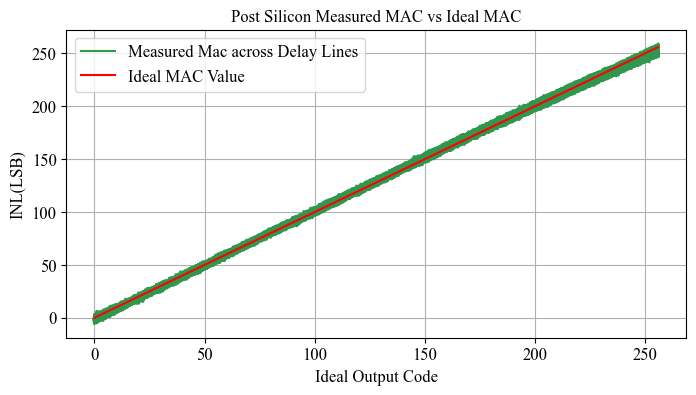

In [33]:
mult = 1
ideal_mac = np.arange(0,256*mult+0.5,1*mult)
x_axis = np.arange(0,257,1)
len(ideal_mac)
print(arr.shape)
corrected = []
error = []
cmap = cm.get_cmap('Blues')
cmap2 = cm.get_cmap('Greens')
fig, ax = plt.subplots(figsize=(8, 4))
plt.title("Post Silicon Measured MAC vs Ideal MAC")
plt.xlabel("Ideal Output Code")
plt.ylabel("INL(LSB)")
slope = []
bias = []
for i in range(256*0,256*4,1): #arr.shape[1]
    #if arr[:,i] < 0 : d1 = 32 - arr[:,i]
    #else: d1 = 32 + arr[:,i] 
    d1 = arr[:, i]
    m, c = np.polyfit(d1,ideal_mac , 1)
    slope.append(m)
    bias.append(c)
    d2 = d1*m+c 
    #plt.plot(ideal_mac, d1, color = cmap(0.3))
    plt.plot(x_axis, d2, color = cmap2(0.7))
    corrected.append(d2)
    error.append(d2 - ideal_mac)
corrected = np.array(corrected)
'''
for point in [50,130,240]:
    mean = np.mean(corrected[:,round(point/4)])
    std = np.std(corrected[:,round(point/4)])
    # Main plot arrow (pointing to feature of interest)
    point = point*mult
    ax.text(point,point-10,f'σ={std:0.3f}',
                fontsize=10)
    ax.errorbar(point, point, yerr=std*5, fmt='o', color='blue', capsize=5, markersize=3)
'''
plt.plot(x_axis, d2, color = cmap2(0.7), label = "Measured Mac across Delay Lines")
plt.plot(x_axis, ideal_mac,color = "Red", label = "Ideal MAC Value")
plt.legend() 
plt.grid(True)
plt.show()

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['font.family'] = 'Times New Roman'   # or 'Times New Roman', 'DejaVu Sans', etc.
mpl.rcParams['font.size'] = 12

# Axis-specific defaults
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 12

In [37]:
corrected.shape


(1024, 257)

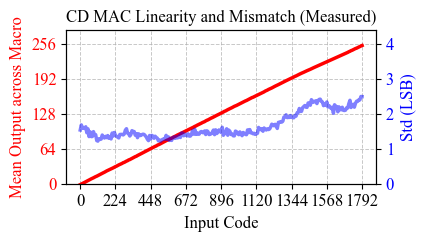

In [21]:
mean_corrected = np.mean(corrected,axis=0)
std_corrected = np.std(corrected,axis=0)
#std_corrected = std_corrected[:len(std_corrected)-5]
#std_corrected[len(std_corrected)-6:len(std_corrected)] = std_corrected[len(std_corrected)-6]
fig, ax1 = plt.subplots(figsize=(4, 2))

# First plot (left y-axis)
ax1.plot(x_axis*7, mean_corrected, color="r",linewidth=2.5)
ax1.set_xlabel("Input Code")
ax1.set_ylabel("Mean Output across Macro", color="r")
ax1.tick_params(axis="y", labelcolor="r")
ax1.set_ylim(0, 140.8 * 2)
ax1.yaxis.set_major_locator(MultipleLocator(32*2))

# Second plot (right y-axis)
ax2 = ax1.twinx()
ax2.plot( x_axis*7,std_corrected, color="b",alpha=0.5,linewidth=2.5)
ax2.set_ylabel("Std (LSB)", color="b")
ax2.tick_params(axis="y", labelcolor="b")
ax2.set_ylim(0, 2.2 * 2)
ax2.yaxis.set_major_locator(MultipleLocator(0.5*2))



plt.xticks(range(0, 256*7+1,32*7)) 
# Optional: title
plt.title("CD MAC Linearity and Mismatch (Measured)")
ax1.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.savefig("D:\ISSCC_26\Graphs\CD_3x_Acc_164.jpg", dpi=800, bbox_inches="tight")
plt.show()

In [34]:
print(np.mean(std_corrected))

1.6444104996744513


(257, 1024) (257, 1024) (257, 1024) (257, 3072)
4.149653287921649


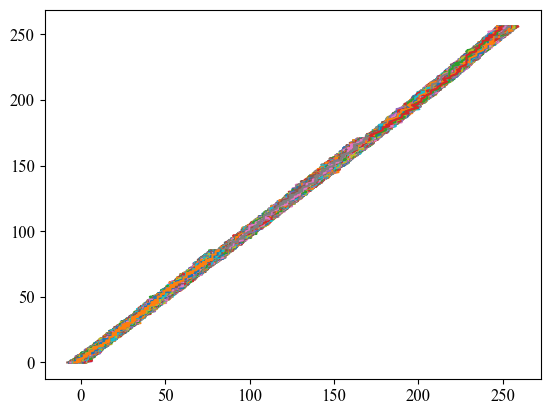

In [ ]:
arr1 = np.load(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\FAST_IMC_SWEEP\ALLBank_1x_CD_Sweep_1_Ref256_900.npy")
arr1 = np.reshape(arr1,(arr1.shape[0],arr1.shape[1]*arr1.shape[2]*arr1.shape[3]))

arr2 = np.load(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\FAST_IMC_SWEEP\ALLBank_1x_CD_Sweep_1_Ref256_800.npy")
arr2 = np.reshape(arr2,(arr2.shape[0],arr2.shape[1]*arr2.shape[2]*arr2.shape[3]))

arr3 = np.load(r"d:\Chip2025_Testing\Python_Notebook\Tests\Data\FAST_IMC_SWEEP\ALLBank_1x_CD_Sweep_1_Ref256_700.npy")
arr3 = np.reshape(arr3,(arr3.shape[0],arr3.shape[1]*arr3.shape[2]*arr3.shape[3]))

arr = np.concatenate((arr1,arr2,arr3),axis=1)
print(arr1.shape,arr2.shape,arr3.shape,arr.shape)
#arr1 = np.transpose(arr1)
temp = []
for i in range(0,arr.shape[1],1): #arr.shape[1]
    if(np.floor(i/1024) == 0):
        factor = 1
        x_axis = np.arange(0,257,1)
    if(np.floor(i/1024) == 1):
        factor = 3/2
        x_axis = np.arange(0,256*2/3+2/3,2/3)
    if(np.floor(i/1024) == 2):
        factor = 3
        x_axis = np.arange(0,256*1/3+1/3,1/3)
    out = (arr[:,i] * slope[i%1024]  + bias[i%1024])
    temp.append(out)
    plt.plot(out,x_axis)
print(np.mean(np.std(temp,axis=0)))

In [24]:
corrected_mac = np.transpose(corrected)
corrected_mac = np.reshape(corrected_mac,(257,4,4,64))
corrected_mac = np.mean(corrected_mac,axis=1)
corrected_mac.shape

(257, 4, 64)

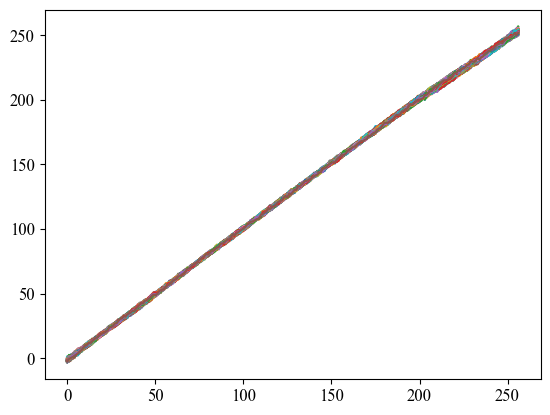

In [25]:
HW_MODEL_CD_1x = np.zeros(((4,64,256*mult+1)),dtype=np.float32)
x_new = np.arange(0, 256*mult+1, 1)   # length 257
x_orig = np.arange(0, 256*mult+1, mult)  # length 65
# Interpolation
for bank in range(4):
    for dl in range(64):
        a = corrected_mac[:,bank,dl]
        HW_MODEL_CD_1x[bank,dl] = np.interp(x_new, x_orig, a)
        plt.plot(HW_MODEL_CD_1x[bank,dl])
#np.save("d:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\Hardware_Model\HW_MODEL_CD_FastIMC.npy",HW_MODEL_CD_1x)

In [ ]:
print(HW_MODEL_CD_1x[0,3,0:50])
print(arr[0:50,3])
print(corrected_mac[0:50,0,3])